Có thể hiểu ý tưởng của resnet bắt đầu từ vấn đề như sau người ta không chắc được việc thêm các lớp vào mạng có cải hiện hoặc làm kém đi so với mạng ban đầu hay không, nếu như không gian hàm sau khi được thêm lớp chứa không gian hàm cũ thì chắc chắn là có thể có hiệu quả tương đường hoặc là hơn so với không gian hàm cũ. Từ đó người ta nghĩ ra cách thêm khối residual vào mạng, khối này có hàm là 
f(x) - x, đầu vào của lớp sau đó là (f(x) - x) + x ta có thể thấy rằng f(x) - x có thể bằng 0 bằng cách cho các trọng số và bias về không điều đó có nghĩa là không gian hàm khi thêm khối residual vào chứa không gian hàm cũ điều này đảm bảo là hiệu quả sẽ không tệ đi

Cấu trúc của resnet
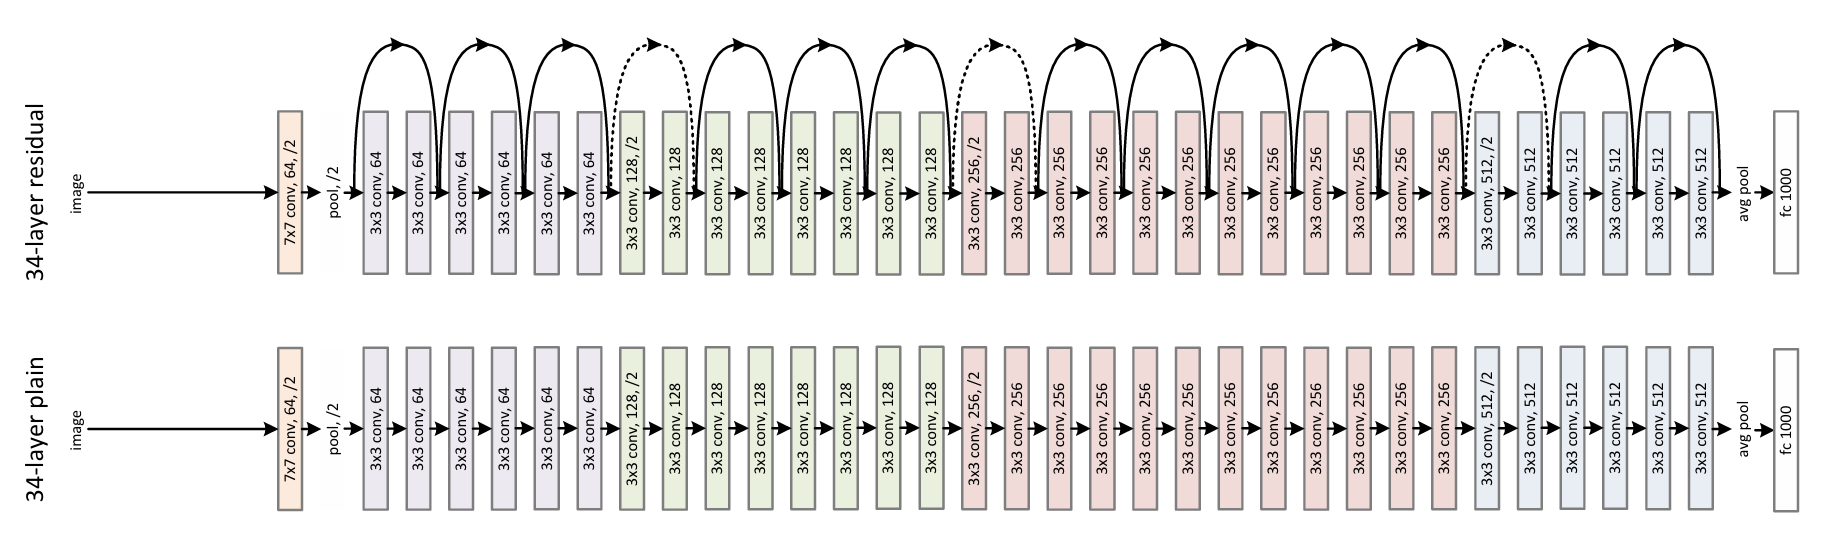
a x b, conv, x (kernel có kích thước a x b, và có tất cả x kernel)
a x b, conv, x, /y (tương tự nhưng có stride là y) đồng nghĩa với kích thước của ảnh giảm đi

paper khảo sát 1 mạng 18 lớp và mạng plain gồm 34 lớp thì mạng 34 lớp có lỗi cao hơn trong tập valid điều này chứng minh rằng nhiều lớp hơn chưa chắc đã tốt hơn và học được sâu hơn. Thử nghiệm trên resnet 34 cho thấy rằng nó tốt hơn hẳn mạng 18 lớp và 34 lớp thống thường với error thấp hơn trên tập valid

![ResNet block with and without $1 \times 1$ convolution.](https://github.com/d2l-ai/d2l-tensorflow-colab/blob/master/img/resnet-block.svg?raw=1)

In [1]:
import torch
import torch.nn as nn

class Residual(nn.Module):
    # các tham số cần thiết: độ sâu của x, số lượng kernel (độ sâu đầu ra của residual và x nếu sử dụng 1x1)
    # nếu không sử dụng 1x1 (trong paper là mũi tên nét đứt) thì tham số in_channel và num_channels là bằng nhau và bằng đúng độ sâu của x
    def __init__(self, in_channels, num_channels, use_1x1conv = False, strides = 1):
    # in_channels số lượng lớp thông tin đầu vào (x), cũng là độ sâu của kernel của conv1
    # num_channels số lượng lớp đầu ra = số kernel
        super(Residual, self).__init__()
        self.conv1 = nn.Conv2d(in_channels = in_channels, out_channels = num_channels, kernel_size = 3, stride = strides, padding = 1)
        # lúc này conv1 có đầu là num channel lớp, nên đầu vào của conv2 là num channel đầu ra cũng là num channel và theo paper thì stride của conv2 luôn là 1
        self.conv2 = nn.Conv2d(in_channels = num_channels, out_channels = num_channels, kernel_size = 3, stride = 1, padding = 1 )
        # hình dung là đầu ra của lớp residual phải cùng shape với x, có nghĩa là cùng cả depth
        # trong paper có 1 số bước phải thêm depth vào x, khi đó phải sử dụng n kernel dạng 1x1
        # để giữ nguyên số chiều của 1 lớp của x và tăng depth của x (khi đi qua 1 kernel đầu ra luôn có depth là 1 đi qua n kernel depth là n)
        self.conv3 = None
        if use_1x1conv:
            self.conv3 = nn.Conv2d(in_channels = in_channels, out_channels = num_channels, kernel_size = 1, stride = strides)
        self.bn1 = nn.BatchNorm2d(num_channels)
        # đầu vào cần thiết của batch norm là số kênh màu
        # nếu có x kênh màu thì có tất cả x bộ giá trị mean var
        self.bn2 = nn.BatchNorm2d(num_channels)

    def forward(self, X):
        Y = nn.ReLU()(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        return nn.ReLU()(Y + X)


In [2]:
# random đầu vào 
# theo quy chuẩn của torch đầu vào có dạng a,b,c,d
# a là batch size, b là chiều sâu c và d là kích thước của ảnh
X = torch.randn((4,3,6,6))
blk = Residual(in_channels = 3, num_channels = 3)
# khi khởi tạo 1 lớp conv thì các kernel của nó đã được khởi tạo sẵn giá trị random rồi
# vì blk kế thừa nn module và có phương thức forward nên có thể làm thế này luôn
assert blk(X).shape == (4,3,6,6)
# assert trả về none khi điều kiện đúng, trả về error khi sai

In [3]:
# với stride là 2, số kênh màu đầu ra là 6 thì ta đã tăng gấp đôi số kênh màu của x 
# và giảm độ phân giải đi 1 nửa
# o = (i+2p-k)/stride + 1, đầu ra mong đợi là các ảnh có chiều 3 3 và có 6 kênh
# vì số chiều bị đổi nên phải sử dụng strides, số kênh màu thay đổi nên phải sử dụng 1x1 conv
blk2 = Residual(in_channels = 3, num_channels = 6, strides = 2, use_1x1conv = True)
blk2(X).shape 

torch.Size([4, 6, 3, 3])

In [4]:
resnet = nn.Sequential()
# lớp đầu tiên là 7x7 conv với 64 kênh màu và stride là 2, giả sử input là ảnh có 3 kênh
# trong resnet lớp đầu thường có padding là 3
resnet.add_module("conv", nn.Conv2d(in_channels = 3, out_channels = 64, kernel_size = 7, stride = 2, padding = 3))
# lớp 2 là batch norm
resnet.add_module("batchnorm", nn.BatchNorm2d(num_features = 64))
# lớp 3 là relu
resnet.add_module("relu", nn.ReLU())
# lớp 4 là maxpool với stride là 2, kernel size là 3x3
resnet.add_module("maxpool", nn.MaxPool2d(kernel_size = 3, padding = 1, stride = 2))
# max pool không cần tham số out channels, nó tự động khớp với số kênh của input
# nếu input có x kênh thì max pool lần lượt thực hiện trên x kênh

thử thêm vào xóa đi nếu lỡ thêm vào 1 lớp thừa

In [5]:
resnet.add_module("useless", nn.MaxPool2d(kernel_size = 3, padding = 1, stride = 2))

In [6]:
resnet

Sequential(
  (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
  (batchnorm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (useless): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
)

In [12]:
resnet._modules

{'conv': Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3)),
 'batchnorm': BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True),
 'relu': ReLU(),
 'maxpool': MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False),
 'useless': MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)}

sử đụng thuộc tính _modules để lấy ra dict bao gồm tên và các lớp trong sequential

In [13]:
del resnet._modules['useless']

In [14]:
resnet

Sequential(
  (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
  (batchnorm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
)

tái hiện lại resnet 18
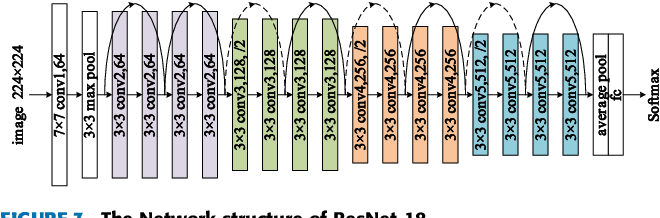

chia ra làm 4 module mỗi module có 2 residual block, chỉ có module đầu tiên có stride là 1 các module sau đó block đầu tiên đều có stride là 2

In [22]:
# in_channels: số kênh đầu vào, num_channels: số kênh đầu ra, num_residuals: số khối phần dư của module
def resnet_block(in_channels, num_channels, num_residuals, first_block = False):
    block = nn.Sequential()
    for i in range(num_residuals):
        if i==0 and not first_block:
        # chỉ các khối residual đầu tiên và không nằm trong block đầu tiên mới có stride là 2 
            block.add_module(f'residual {i}', Residual(in_channels = in_channels, num_channels = num_channels, strides = 2, use_1x1conv = True))
        else:
            block.add_module(f'residual {i}', Residual(in_channels = num_channels, num_channels = num_channels))
    return block

In [23]:
resnet.add_module('resnet_block1', resnet_block(64, 64,2, first_block = True))
resnet.add_module('resnet_block2', resnet_block(64, 128,2))
resnet.add_module('resnet_block3', resnet_block(128, 256,2))
resnet.add_module('resnet_block4', resnet_block(256, 512, 2))

In [24]:
resnet

Sequential(
  (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
  (batchnorm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (resnet_block1): Sequential(
    (residual 0): Residual(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (residual 1): Residual(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): Batc

Sau khi qua 4 module đầu ra sẽ có dạng là batch, channels, h, w. Các lớp cuối cùng là:
* 1 avg pool (yêu cầu output là 1x1, đồng nghĩa với việc là kernel của pool phải có cùng kích thước của ảnh, có thể sử dụng adaptive pool để nó tự tính toán kernel). đầu ra của avg pool sẽ là batch, channels,1,1
* Sau khi có dược output dạng batch,c,1,1 ta cần flat ra thành batch,c có thể hiểu là batch ảnh và mỗi ảnh có 1 vector gồm c chiều
* sau đó nhân với 1 ma trận với chiều là c*label để tạo thành ma trận dạng batch * labels quen thuộc

In [25]:
resnet.add_module('globalAvr', nn.AdaptiveAvgPool2d((1,1)))
resnet.add_module('flatten', nn.Flatten())
resnet.add_module('fc', nn.Linear(512,10))

In [26]:
resnet

Sequential(
  (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
  (batchnorm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (resnet_block1): Sequential(
    (residual 0): Residual(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (residual 1): Residual(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): Batc

In [31]:
# thử xem shape đầu ra của đầu vào ngẫu nhiên với số kênh màu là 3
randX = torch.randn((36,3,224,224))
resnet(randX).shape

torch.Size([36, 10])